# ※ 과제 안내
- 과제 배점: 각 문제당 10점, 총점 100점입니다. 부분 점수는 제공되지 않습니다.  

- 채점 기준:  
    - 출력 결과 일치: 제출한 코드가 제시된 출력 결과와 일치하는 경우에만 정답으로 인정됩니다.  
    - 코드의 다양성 인정: 출력 결과가 동일하다면 다양한 접근 방식을 존중하여 정답으로 인정합니다.

- 제출시, O주차_OOO.ipynb로 제출 바랍니다.

---
# 12주차 과제

In [ ]:
import warnings
warnings.filterwarnings('ignore')

---
# Q1. Bidirectional Elman RNN 이진 분류

In [ ]:
# === 1-1: 라이브러리 및 유틸 함수 ===
import numpy as np
np.random.seed(2025)

# Xavier 초기화를 직접 구현하여 가중치 분포와 스케일링 원리를 이해한다.
def xavier_init(shape):
    # --- 문제 시작 ---


    # --- 문제 끝 ---

# one-hot 인코딩 함수를 구현해 정수 인덱스를 벡터 표현으로 변환하는 과정을 연습한다.
def one_hot(x, D):
    # --- 문제 시작 ---



    # --- 문제 끝 ---


In [ ]:
# === 1-2: 데이터 생성 및 미니배치 제너레이터 ===

# 시퀀스 데이터를 생성하여 0/1 랜덤 시퀀스와 짝수/홀수 레이블을 반환합니다.
def generate_data(N, seq_len=20):
    X = np.random.randint(0,2,(N,seq_len))
    y = X.sum(axis=1) % 2
    return X, y

# 미니배치 단위로 데이터를 셔플링하여 (X_batch, y_batch)를 순차적으로 반환하는 제너레이터입니다.
def get_minibatches(X, y, batch_size):
    # --- 문제 시작 ---





    # --- 문제 끝 ---

X_train, y_train = generate_data(3000)
X_val,   y_val   = generate_data(600)
X_test,  y_test  = generate_data(600)


In [ ]:
# === 1-3: 파라미터 초기화 ===
# Xavier 초기화로 가중치 분포를 조절하고 드롭아웃 확률을 설정하여 과적합을 방지합니다.
D, H, C = 1, 64, 2
reg_lambda = 1e-4
drop_prob = 0.3

# forward RNN
# --- 문제 시작 ---



# backward RNN



# 출력층


# --- 문제 끝 ---


In [ ]:
# === 1-4: Dropout 마스크 함수 ===
# 드롭아웃을 통해 은닉 유닛 일부를 확률적으로 제거하여 과적합을 방지합니다.
def dropout_mask(shape, p):
    # --- 문제 시작 ---
    mask =
    return mask
    # --- 문제 끝 ---


In [ ]:
# 은닉 상태를 순방향/역방향으로 갱신하고 드롭아웃을 적용하는 순전파 과정을 직접 구현합니다.
# === 1-5: 순전파 (Bidirectional + Dropout) ===
def forward(x_batch, apply_dropout=True):
    B, T = x_batch.shape
    h_f = np.zeros((H,B)); h_b = np.zeros((H,B))
    cache = []
    # forward RNN
    for t in range(T):
        xt = x_batch[:,t].reshape(1,B)
        m = dropout_mask((H,B), drop_prob) if apply_dropout else np.ones((H,B))
        # --- 문제 시작 ---


        # --- 문제 끝 ---
        cache.append([h_f.copy(), m, None])
    # backward RNN
    for t in reversed(range(T)):
        xt = x_batch[:,t].reshape(1,B)
        m = dropout_mask((H,B), drop_prob) if apply_dropout else np.ones((H,B))
        # --- 문제 시작 ---


        # --- 문제 끝 ---
        cache[t][2] = (h_b.copy(), m)
    # 출력층
    H_cat = np.vstack([h_f, h_b])
    logits = Wo.dot(H_cat) + bo
    return logits, cache


In [ ]:
# Cross-entropy 손실에 L2 정규화를 더하고, 배치 정확도를 계산합니다.
# === 1-6: 손실 및 정확도 계산 ===
def compute_loss_and_acc(logits, y_batch):
    B = logits.shape[1]
    # --- 문제 시작 ---
    exp =
    probs =
    correct =
    loss =
    acc =
    # --- 문제 끝 ---
    return loss, acc


In [ ]:
# === 1-7: 역전파 (Bidirectional BPTT + Gradient Clipping) ===
# 순방향과 역방향 RNN에 대한 역전파를 수행하고 gradient clipping을 적용합니다.
def backward(logits, cache, x_batch, y_batch, clip=5.0):
    B, T = x_batch.shape
    # --- 문제 시작 ---












    # forward BPTT
    for t in reversed(range(T)):








    # backward BPTT
    for t in range(T):








    for g in [dWx_f, dWh_f, dbh_f, dWx_b, dWh_b, dbh_b, dWo, dbo]:
        np.clip(g, -clip, clip, out=g)
    # --- 문제 끝 ---
    return {
        'Wx_f': dWx_f, 'Wh_f': dWh_f, 'bh_f': dbh_f,
        'Wx_b': dWx_b, 'Wh_b': dWh_b, 'bh_b': dbh_b,
        'Wo'  : dWo,   'bo'  : dbo
    }


In [ ]:
# === 1-8: 학습 루프 및 테스트 ===
lr = 0.01
for epoch in range(30):
    for Xb, yb in get_minibatches(X_train, y_train, 64):
        logits, cache = forward(Xb)
        grads = backward(logits, cache, Xb, yb)
        # --- 문제 시작 ---


        # --- 문제 끝 ---
        # validation
        logits_val, _ = forward(X_val, apply_dropout=False)
        vl, va = compute_loss_and_acc(logits_val, y_val)
    print(f"Epoch {epoch} val_acc={va:.4f}")

# logits, cache 언패킹
logits_test, _ = forward(X_test, apply_dropout=False)

# compute_loss_and_acc에 (logits, y_test) 두 개만 전달
tl, ta = compute_loss_and_acc(logits_test, y_test)
print("Final Test Accuracy:", ta)


Epoch 0 val_acc=0.4817
Epoch 1 val_acc=0.4517
Epoch 2 val_acc=0.4950
Epoch 3 val_acc=0.5083
Epoch 4 val_acc=0.5083
Epoch 5 val_acc=0.5083
Epoch 6 val_acc=0.5083
Epoch 7 val_acc=0.5083
Epoch 8 val_acc=0.5083
Epoch 9 val_acc=0.5083
Epoch 10 val_acc=0.5083
Epoch 11 val_acc=0.5083
Epoch 12 val_acc=0.5083
Epoch 13 val_acc=0.5083
Epoch 14 val_acc=0.5083
Epoch 15 val_acc=0.5083
Epoch 16 val_acc=0.5083
Epoch 17 val_acc=0.5083
Epoch 18 val_acc=0.5083
Epoch 19 val_acc=0.5083
Epoch 20 val_acc=0.5083
Epoch 21 val_acc=0.5083
Epoch 22 val_acc=0.5083
Epoch 23 val_acc=0.5083
Epoch 24 val_acc=0.5083
Epoch 25 val_acc=0.5083
Epoch 26 val_acc=0.5250
Epoch 27 val_acc=0.5083
Epoch 28 val_acc=0.4917
Epoch 29 val_acc=0.5250
Final Test Accuracy: 0.5083333333333333


---
# Q2. Seq2Seq with Bahdanau Attention

In [ ]:
# === 2-1: 라이브러리 및 헬퍼 ===
import numpy as np
np.random.seed(2025)

def xavier(shape):
    # --- 문제 시작 ---

    # --- 문제 끝 ---

def one_hot(x, D):
    # --- 문제 시작 ---

    # --- 문제 끝 ---
    return v


In [ ]:
# === 2-2: 데이터 준비 ===
# 예: 입력 "ABC", 목표 "ABC"
chars = list("ABC")
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}
seqs = [["A","B","C"], ["B","A","C"]]
data = [([char2idx[c] for c in s],[char2idx[c] for c in s]) for s in seqs]
V, H = len(chars), 64


In [ ]:
# === 2-3: 파라미터 초기화 (인코더) ===
# 단층 GRU 인코더
We = xavier((H,V));    # 임베딩→hidden
Ue = xavier((H,H));    # hidden→hidden
be = np.zeros((H,1))   # bias


In [ ]:
# === 2-4: 파라미터 초기화 (디코더 + 어텐션) ===
Wd = xavier((H, V));   Ud = xavier((H, H));   bd = np.zeros((H,1))
Wa = xavier((H, 2*H)); ba = np.zeros((H,1))

# --- 문제 시작 ---


# --- 문제 끝 ---

Wo = xavier((V, H));    bo = np.zeros((V,1))


In [ ]:
# === 2-5: 인코더 순전파 ===
def encode(x_seq):
    h = np.zeros((H,1))
    states = []
    for ix in x_seq:
        xt = one_hot(ix,V)
        # --- 문제 시작 ---

        # --- 문제 끝 ---
        states.append(h.copy())
    return states


In [ ]:
# 2-4 셀에 다음을 추가로 정의해야 합니다.
# attention 가중치 벡터 v_a (H차원 → 스칼라 score)
v_a = xavier((1, H))

# === 2-6: Bahdanau 어텐션 ===
def attend(ht, enc_states):
    """
    ht: (H,1) 디코더 현재 은닉 상태
    enc_states: [(H,1), …] 인코더 각 타임스텝 은닉 상태 리스트
    returns: context (H,1), alpha (T,)
    """
    # --- 문제 시작 ---
    # score 계산
    scores = []
    for hs in enc_states:






    # softmax로 정규화


    # context 벡터 계산 (가중합)
    context = sum(alpha[t] * enc_states[t] for t in range(len(enc_states)))  # (H,1)
    # --- 문제 끝 ---

    return context, alpha



In [ ]:
# === 2-7: 디코더 순전파 + 손실 계산 ===
def decode(enc_states, y_seq):
    h = np.zeros((H,1)); loss = 0
    for iy in y_seq:
        yt = one_hot(iy, V)
        # --- 문제 시작 ---
        # 1) 어텐션 컨텍스트 계산

        # 2) 디코더 은닉 상태 업데이트 (피드포워드 + 컨텍스트)

        # 3) 출력 logits 및 확률 계산




        # 4) 크로스엔트로피 손실 누적
        loss += -np.log(p[iy, 0])
        # --- 문제 끝 ---
    return loss


In [ ]:
# === 2-8: 역전파 및 파라미터 업데이트 ===
def train_step(x_seq, y_seq, lr=0.01, eps=1e-5):
    """
    역전파를 수치 미분(numeric gradient)으로 대체하여,
    모든 파라미터에 대해 gradient를 구한 뒤 SGD update를 수행합니다.
    """
    # --- 문제 시작 ---
    # 1) 현재 loss 계산



    # 2) 업데이트할 파라미터 리스트와 이름
    params = {
        'We': We, 'Ue': Ue, 'be': be,
        'Wd': Wd, 'Ud': Ud, 'bd': bd,
        'Wa': Wa, 'ba': ba,
        'Wc': Wc, 'bc': bc,
        'Wo': Wo, 'bo': bo,
        'v_a': v_a
    }

    grads = {}
    # 3) 수치미분으로 파라미터별 gradient 계산
    for name, param in params.items():
        grad = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            orig = param[idx]

            # f(x + eps)


            # f(x - eps)


            # numeric gradient



        grads[name] = grad

    # 4) SGD 업데이트
    for name, param in params.items():

    # --- 문제 끝 ---

    return base_loss


In [ ]:
# === 2-9: 학습 루프 (미니배치) ===
for epoch in range(30):
    total_loss=0
    for x_seq, y_seq in data:
        total_loss += train_step(x_seq, y_seq)
    if epoch%5==0:
        print(f"Epoch {epoch}, loss={total_loss:.4f}")


Epoch 0, loss=1.4618
Epoch 5, loss=1.1934
Epoch 10, loss=0.9961
Epoch 15, loss=0.8470
Epoch 20, loss=0.7314
Epoch 25, loss=0.6400


---
# Q3. Multi-Head Self-Attention 인코더 레이어 구현




In [ ]:
# === 3-1: 라이브러리 및 헬퍼 함수 ===
import numpy as np
np.random.seed(2025)

def xavier_init(shape):
    # --- 문제 시작 ---


    # --- 문제 끝 ---

def softmax(x, axis=-1):
    # --- 문제 시작 ---


    # --- 문제 끝 ---

def split_heads(x, num_heads):
    B,T,D = x.shape
    # --- 문제 시작 ---


    # --- 문제 끝 ---
    return x.transpose(0,2,1,3)

def combine_heads(x):
    B,H,T,depth = x.shape
    # --- 문제 시작 ---

    # --- 문제 끝 ---
    return x.reshape(B, T, H*depth)


IndentationError: expected an indented block after function definition on line 5 (ipython-input-2539718049.py, line 11)

In [ ]:
# === 3-2: 파라미터 초기화 ===
D = 512
N_HEADS = 8
DEPTH = D // N_HEADS
D_FF = 2048

# --- 문제 시작 ---
# Q,K,V projection



# output projection

# layernorm 파라미터
gamma1 =
gamma2 =
# FFN 파라미터
W1 =
W2 =
# --- 문제 끝 ---

# dropout 비율
dropout_rate = 0.1


In [ ]:
# === 3-3: Scaled Dot-Product Attention ===
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q,K,V: (B, heads, T, depth)
    # --- 문제 시작 ---
    scores = Q @ K.transpose(0,1,3,2) / np.sqrt(DEPTH)





    # --- 문제 끝 ---
    return out, attn


In [ ]:
# === 3-4: Multi-Head Attention Forward ===
def multi_head_attention(X, mask=None):
    # X: (B, T, D)
    # --- 문제 시작 ---
    Q =
    K =
    V =
    Qh =
    Kh =
    Vh =






    # --- 문제 끝 ---
    return out, mh_attn


In [ ]:
# === 3-5: LayerNorm ===
def layer_norm(x, gamma, beta, eps=1e-6):
    # x: (B, T, D)
    # --- 문제 시작 ---




    return gamma * xn + beta
    # --- 문제 끝 ---


In [ ]:
# === 3-6: Feed-Forward Network ===
def feed_forward(x):
    # x: (B, T, D)
    # --- 문제 시작 ---




    # --- 문제 끝 ---
    return z


In [ ]:
# === 3-7: Encoder Layer Forward ===
def encoder_layer(X, mask=None):
  # --- 문제 시작 ---
    # 1) Multi‐Head Attention

    # 2) Residual + LayerNorm1


    # 3) Feed-Forward

    # 4) Residual + LayerNorm2
 # --- 문제 끝 ---


    # --- 문제: backward를 위해 이 키들을 반드시 채워줍니다 ---
    cache = {
      'mh_cache':   None,     # multi_head 내부 캐시(테스트용 스텁에서는 사용 안 함)
      'ln1_cache':  None,     # layer_norm1 캐시
      'out1':       out1,
      'ffn_out':    ffn_out,
      'ln2_cache':  None,     # layer_norm2 캐시
      'attn_out':   attn_out,
      'X':          X,
      'res1':       res1,
      'res2':       res2
    }
    # ----------------------------------------------------

    return out2, attn_w, cache


In [ ]:
# === 3-8: Encoder Layer Backward + Gradient Clipping ===
def encoder_layer_backward(dout, cache, clip=1.0):
    """
    cache = {
      'X':         X,             # (B,T,D)
      'attn_out': attn_out,       # (B,T,D)
      'out1':     out1,           # (B,T,D)
      'ffn_out':  ffn_out,        # (B,T,D)
      'mh_cache': mh_cache,       # cache from multi_head_attention()
      'ln1_cache': ln1_cache,     # cache from layer_norm(X+attn_out)
      'ln2_cache': ln2_cache      # cache from layer_norm(out1+ffn_out)
    }
    dout: gradient w.r.t. out2 (B,T,D)
    """
    # --- 문제 시작 ---
    # 1) LayerNorm2 역전파 → d_ffn_out, d_res1

    # 2) Feed-Forward 역전파 → dW1, db1, dW2, db2, d_out1

    # 3) LayerNorm1 역전파 → d_attn_out, d_X

    # 4) Multi-Head Attention 역전파 → dWq, dWk, dWv, dWo, dbo, dX_attn_input


     # 5) 합산 residual gradient for X

    # 6) Gradient clipping
    for g in [dW1, db1, dW2, db2, dWq, dbq, dWk, dbk, dWv, dbv, dWo, dbo]:
        np.clip(g, -clip, clip, out=g)
    # --- 문제 끝 ---
    return {
        'W1':  dW1,  'b1':  db1,
        'W2':  dW2,  'b2':  db2,
        'Wq':  dWq,  'bq':  dbq,
        'Wk':  dWk,  'bk':  dbk,
        'Wv':  dWv,  'bv':  dbv,
        'Wo':  dWo,  'bo':  dbo
    }


In [ ]:
# === 3-9 Encoder Layer Backward Helper 함수 구현 ===
# 다음 세 가지 스텁 함수를 완성하세요.
# 1) layer_norm_backward: forward에서 저장된 평균/분산/감마·베타를 활용해 dx와 residual gradient 계산
# 2) feed_forward_backward: FFN 순전파 시 저장된 중간값(cache)을 이용해 dx, dW1, db1, dW2, db2 계산
# 3) multi_head_attention_backward: self-attention forward 캐시를 활용해 dX와 모든 파라미터 기울기 계산

# --- 문제 시작 ---
def layer_norm_backward(dout, cache):
    """
    테스트용 스텁:
    - dx: 바로 dout 전달
    - d_residual: 동일한 shape의 zero 배열 전달
    """





def feed_forward_backward(d_ffn_out, cache):
    """
    간단 스텁: feed_forward(x) → z 로 만들 때,
    backward에서는 gradient를 그대로 x로 전파하고
    파라미터 gradient는 모두 0으로 채워줍니다.
    반환: (dx, dW1, db1, dW2, db2)
    """
    x = cache   # 캐시에 x를 저장했다고 가정





def multi_head_attention_backward(d_attn, mh_cache):
    """
    간단 스텁: multi_head_attention(X) → out 으로 만들 때,
    backward에서는 gradient를 그대로 X로 전파하고
    파라미터 gradient는 모두 0으로 채워줍니다.
    반환: (dX, dWq, dbq, dWk, dbk, dWv, dbv, dWo, dbo)
    """
    # mh_cache도 실제로 필요 없으므로 무시
    dX = d_attn   # residual에 더해질 입력 gradient




# --- 문제 끝 ---


In [ ]:
# === 3-10 테스트 코드 ===
import numpy as np

# 하이퍼파라미터 (문제 정의와 동일)
D = 512
N_HEADS = 8
D_FF = 2048
dropout_rate = 0.1

# 더미 입력 생성: 배치 크기 2, 시퀀스 길이 10
X_dummy = np.random.randn(2, 10, D)
mask = None  # 마스크 없이 테스트

# 1) forward 호출 (cache도 함께 반환한다고 가정)
out2, attn_w, cache5 = encoder_layer(X_dummy, mask)

print("Encoder output shape:", out2.shape)      # 기대: (2, 10, D)
print("Attention weights shape:", attn_w.shape)  # 기대: (2, N_HEADS, 10, 10)

# 2) 임의의 gradient 생성 및 backward 호출
dout = np.random.randn(*out2.shape)
grads5 = encoder_layer_backward(dout, cache5, clip=0.5)

# 3) 각 파라미터 gradient 크기 확인
for name, grad in grads5.items():
    print(f"{name}: {grad.shape}")


# Q4. Masked Transformer 디코더 레이어 + 단일 토큰 샘플링

In [ ]:
# === 4-1: 라이브러리 및 헬퍼 함수 ===
import numpy as np
np.random.seed(2025)

def xavier_init(shape):
    # --- 문제 시작 ---


    # --- 문제 끝 ---

def softmax(x, axis=-1):
    # --- 문제 시작 ---


    # --- 문제 끝 ---

def create_causal_mask(T):
    # --- 문제 시작 ---


    # --- 문제 끝 ---


In [ ]:
# === 4-2: 파라미터 초기화 ===
D = 512; N_HEADS = 8; DEPTH = D//N_HEADS; D_FF = 2048

# --- 문제 시작 ---
# Self-Attention (masked)

# Cross-Attention


# Output projection

# LayerNorm 파라미터



# FFN 파라미터


# --- 문제 끝 ---

dropout_rate=0.1


In [ ]:
# === 4-3: Masked Self-Attention Forward ===
def masked_self_attention(X):
    B,T,D = X.shape
    mask = create_causal_mask(T)
    # --- 문제 시작 ---
    Q =
    K =
    V =





    # --- 문제 끝 ---
    return Y, attn


In [ ]:
# === 4-4: Cross-Attention Forward ===
def cross_attention(X, enc_out):
    # X: (B,T_dec,D), enc_out: (B,T_enc,D)
    # --- 문제 시작 ---
    Q =
    K =
    V =






    # --- 문제 끝 ---
    return Y, attn


In [ ]:
# === 4-5: Decoder Layer Forward ===
def decoder_layer(X, enc_out):
  # --- 문제 시작 ---
    # 1) Masked Self-Attention


    # 2) Cross-Attention




    # 3) Feed-Forward




    # --- 문제 끝 ---
    # backward에 필요한 모든 중간값을 cache에 저장
    cache = {
        'msa_cache':  None,   # masked_self_attention 내부 캐시
        'ln1_cache':  None,   # layer_norm after self-attn
        'out1':       out1,   # layer_norm1 출력
        'ca_cache':   None,   # cross_attention 내부 캐시
        'ln2_cache':  None,   # layer_norm after cross-attn
        'out2':       out2,   # layer_norm2 출력
        'ffn_cache':  None,   # feed_forward 내부 캐시
        'ln3_cache':  None    # layer_norm after FFN
    }

    return out3, msa_w, ca_w, cache


In [ ]:
# === 4-6: 단일 토큰 샘플링 ===
def generate_one_step(prefix_tokens, enc_out):
    """
    prefix_tokens: (B, t) 디코더 입력
    enc_out: (B, T_enc, D) 인코더 출력
    """
    # --- 문제 시작 ---
    B, t = prefix_tokens.shape
    # 1) 최근 토큰만 one-hot 임베딩 → X: (B, 1, V)




    # 2) 디코더 레이어 한 스텝 실행
    # out: (B, 1, D)

    # 3) 마지막 타임스텝 logits 추출
    # (B, D)

    # 4) 확률 계산
    # (B, D)

    # 5) 가장 확률 높은 토큰 선택
    # (B,)

    # 6) 반환
    return next_token
    # --- 문제 끝 ---


In [ ]:
# === 4-7: 단일 토큰 샘플링 (임베딩 추가) ===
V, D = len(char2idx), 512
E = np.random.randn(V, D) * np.sqrt(2.0/(V + D))


def generate_one_step(prefix_tokens, enc_out):
    """
    prefix_tokens: (B, t) 디코더 입력 인덱스
    enc_out:       (B, T_enc, D) 인코더 출력
    """
    # --- 문제 시작 ---
    B, t = prefix_tokens.shape

    # 1) 최근 토큰 one-hot → (B,1,V)




    # 2) one-hot 임베딩 → (B,1,D)


    # 3) 디코더 레이어 한 스텝 실행


    # 4) 마지막 시점 logits → (B,D)


    # 5) softmax → 확률
    probs =

    # 6) 다음 토큰 인덱스 선택
    next_token = # (B,)

    # --- 문제 끝 ---

    return next_token


In [ ]:
# === 4-8: Decoder Layer Backward + Gradient Clipping ===
def decoder_layer_backward(dout, cache, clip=1.0):
    """
    dout: gradient of out3 (B, T, D)
    cache: {
      'X': X,                   # (B,T,D)
      'msa_out': msa_out,       # (B,T,D)
      'out1': out1,             # (B,T,D)
      'ca_out': ca_out,         # (B,T,D)
      'out2': out2,             # (B,T,D)
      'ff_out': ff_out,         # (B,T,D)
      'msa_cache': msa_cache,   # masked_self_attention internals
      'ca_cache': ca_cache,     # cross_attention internals
      'ln1_cache': ln1_cache,   # LayerNorm after self-attn
      'ln2_cache': ln2_cache,   # LayerNorm after cross-attn
      'ln3_cache': ln3_cache    # LayerNorm after FFN
    }
    """
    # --- 문제 시작 ---
    # 1) LayerNorm3 역전파 → d_ffn_out, d_res2


    # 2) Feed-Forward 역전파 → d_out2, dW1_d, db1_d, dW2_d, db2_d


    # 3) residual gradient to out2 input


    # 4) LayerNorm2 역전파 → d_ca_out, d_res1


    # 5) Cross-Attention 역전파 → d_out1, dWq_c, dbq_c, dWk_c, dbk_c, dWv_c, dbv_c, dWo_c, dbo_c


    # 6) residual gradient to out1 input


    # 7) LayerNorm1 역전파 → d_msa_out, d_X1


    # 8) Masked Self-Attention 역전파 → d_X0, dWq_s, dbq_s, dWk_s, dbk_s, dWv_s, dbv_s, dWo_s, dbo_s


    # 9) residual gradient to X input


    # 10) gradient clipping





    # --- 문제 끝 ---

    return {
      'W1_d': dW1_d, 'b1_d': db1_d, 'W2_d': dW2_d, 'b2_d': db2_d,
      'Wq_c': dWq_c, 'bq_c': dbq_c, 'Wk_c': dWk_c, 'bk_c': dbk_c,
      'Wv_c': dWv_c, 'bv_c': dbv_c, 'Wo_c': dWo_c, 'bo_c': dbo_c,
      'Wq_s': dWq_s, 'bq_s': dbq_s, 'Wk_s': dWk_s, 'bk_s': dbk_s,
      'Wv_s': dWv_s, 'bv_s': dbv_s, 'Wo_s': dWo_s, 'bo_s': dbo_s,
      'dX': dX
    }


In [ ]:
# === 4-9: Backward 헬퍼 함수 스텁 정의 ===

def masked_self_attention_backward(dmsa, cache):
    """
    스텁: masked_self_attention(X) → out
    backward: gradient를 X로 되돌리고 파라미터 gradient는 0으로 채웁니다.
    반환: dX, dWq_s, dbq_s, dWk_s, dbk_s, dWv_s, dbv_s, dWo_s, dbo_s
    """
    # --- 문제 시작 ---
    dX = dmsa  # residual 입력으로 그대로 전파




    # --- 문제 끝 ---
    return dX, zero_Wq, zero_bq, zero_Wk, zero_bk, zero_Wv, zero_bv, zero_Wo, zero_bo

def cross_attention_backward(dca, cache):
    """
    스텁: cross_attention(Q,K,V) → out
    backward: gradient를 out2 입력에 되돌리고 파라미터 gradient는 0으로 채웁니다.
    반환: dX (decoder input), dWq_c, dbq_c, dWk_c, dbk_c, dWv_c, dbv_c, dWo_d, dbo_d
    """
    # --- 문제 시작 ---
    dX = dca





    # --- 문제 끝 ---
    return dX, zero_Wq, zero_bq, zero_Wk, zero_bk, zero_Wv, zero_bv, zero_Wo, zero_bo


In [ ]:
# === 4-10: 테스트 코드 ===
import numpy as np

# 하이퍼파라미터
D     = 512
V     = len(char2idx)   # 어휘 크기
N_HEADS = 8
T_enc = 10
T_dec = 5
B     = 2

# 더미 인코더 출력
enc_out = np.random.randn(B, T_enc, D)

# 더미 prefix
prefix = np.random.randint(0, V, size=(B, T_dec))

# 1) 임베딩 매트릭스 생성
E = np.random.randn(V, D) * np.sqrt(2.0/(V+D))   # xavier like

# 2) one-hot → 임베딩
X_onehot = np.zeros((B, 1, V))
for i, tok in enumerate(prefix[:, -1]):
    X_onehot[i, 0, tok] = 1

# (B,1,D) 크기의 임베딩 입력
X_step = X_onehot @ E    # matmul over last dim: (B,1,V) @ (V,D) → (B,1,D)

# 3) One-step 샘플링
next_tokens = generate_one_step(prefix, enc_out)
print("Next tokens:", next_tokens)

# 4) 디코더 forward/backward 테스트
out3, msa_w, ca_w, cache6 = decoder_layer(X_step, enc_out)
print("Decoder out shape:", out3.shape)       # (B,1,D)
print("MSA w shape:",     msa_w.shape)        # (B, N_HEADS, 1, 1)
print("Cross-attn w shape:", ca_w.shape)      # (B, N_HEADS, 1, T_enc)

dout3 = np.random.randn(*out3.shape)
grads6 = decoder_layer_backward(dout3, cache6, clip=0.5)
for name, g in grads6.items():
    print(name, g.shape)


Next tokens: [ 36 346]
Decoder out shape: (2, 1, 512)
MSA w shape: (2, 8, 1, 1)
Cross-attn w shape: (2, 8, 1, 10)
W1_d (2048, 512)
b1_d (2048,)
W2_d (512, 2048)
b2_d (512,)
Wq_c (512, 512)
bq_c (512,)
Wk_c (512, 512)
bk_c (512,)
Wv_c (512, 512)
bv_c (512,)
Wo_c (512, 512)
bo_c (512,)
Wq_s (512, 512)
bq_s (512,)
Wk_s (512, 512)
bk_s (512,)
Wv_s (512, 512)
bv_s (512,)
Wo_s (512, 512)
bo_s (512,)
dX (2, 1, 512)


---
# Q5. temperature 조절·Top-k·Nucleus 샘플링 구현


In [ ]:
# === 5-1: 라이브러리 및 소프트맥스 정의 ===
import numpy as np
np.random.seed(2025)

def softmax(logits, axis=-1):
    # --- 문제 시작 ---
    # 수치 안정화: logits - max(logits)


    # --- 문제 끝 ---


In [ ]:
# === 5-2: temperature 조절 샘플링 ===
def sample_with_temperature(logits, temperature=1.0):
    """
    logits: 1D array of shape (V,)
    temperature: float > 0
    returns: index sampled
    """
    # --- 문제 시작 ---
    # 1) logits를 temperature로 나누어 스케일링

    # 2) softmax로 확률 분포 계산

    # 3) 분포에 따라 토큰 인덱스 샘플링

    # --- 문제 끝 ---


In [ ]:
# === 5-3: Top-k 샘플링 ===
def sample_top_k(logits, k=5):
    """
    logits: 1D array of shape (V,)
    k: int, top-k 유지
    returns: index sampled
    """
    # --- 문제 시작 ---
    # 1) softmax로 확률 분포 계산

    # 2) 확률이 큰 순서대로 k개 인덱스 선택

    # 3) 나머지 인덱스 확률은 0으로, top-k 확률만 남겨서 재정규화



    # 4) mask를 기반으로 토큰 샘플링

    # --- 문제 끝 ---


In [ ]:
# === 5-4: Nucleus (Top-p) 샘플링 ===
def sample_top_p(logits, p=0.9):
    """
    logits: 1D array of shape (V,)
    p: float in (0,1]
    returns: index sampled
    """
    # --- 문제 시작 ---
    # 1) softmax로 확률 분포 계산

    # 2) 확률 내림차순 정렬된 인덱스 및 확률


    # 3) 누적합 계산하여 threshold 초과 지점 찾기


    # 4) top-p 인덱스만 남기고 나머지는 0으로




    # 5) renormalize

    # 6) masked 분포로 샘플링

    # --- 문제 끝 ---


In [ ]:
# === 5-5: 테스트 코드 ===
V = 20
logits = np.random.randn(V)

print("Temp=0.7 sample:", sample_with_temperature(logits, 0.7))
print("Top-5 sample:", sample_top_k(logits, 5))
print("Top-p(0.8) sample:", sample_top_p(logits, 0.8))


Temp=0.7 sample: 5
Top-5 sample: 8
Top-p(0.8) sample: 16


---
# Q6. Chain-of-Thought Prompting + Self-Consistency
LLM을 이용해 직접 답변(direct answering), CoT(Chain-of-Thought), 그리고 Self-Consistency 세 가지 방식으로 동일한 수리·논리 문제를 풀고, 성능을 비교·평가하세요.
Self-Consistency는 “여러 번의 CoT 출력을 뽑아서, 각 체인의 마지막 답안만 모아서 다수결로 최종 정답을 선택”하는 방법입니다.

In [ ]:
# === 6-1: 라이브러리 import 및 모델 로딩 ===
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, GenerationConfig

# 사용할 모델 이름(여러 모델로 실험할 확장성 고려한 설계)
MODEL_NAMES = [
    "google/flan-t5-xl",
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# --- 문제 시작 ---
tokenizers = {}
models     = {}
for name in MODEL_NAMES:
    tokenizer = AutoTokenizer.from_pretrained(name)
    model     = AutoModelForSeq2SeqLM.from_pretrained(name, torch_dtype=torch.float16).to(DEVICE)
    tokenizer.padding_side  = "left"
    tokenizer.pad_token     = tokenizer.eos_token
    tokenizers[name] = tokenizer
    models[name]     = model
# --- 문제 끝 ---

model.safetensors.index.json:   0%|          | 0.00/53.0k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.45G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# === 6-2: 프롬프트 생성 함수 ===
def make_prompt(question: str,
                style: str = "direct",
                cot_suffix: str = "Let's think step by step.") -> str:
    """
    style:
      - "direct":   "{question}\nAnswer:"
      - "chain":    "Question: {q}\nHint: {cot_suffix}\nAnswer:"
    """
    if style == "direct":
      # --- 문제 시작 ---

      # --- 문제 끝 ---
    elif style == "chain":
      # --- 문제 시작 ---

      # --- 문제 끝 ---
    else:
        raise ValueError(f"unknown style={style}")

In [ ]:
# === 답안 생성 함수들 ===
def generate_direct(question, model_name):
    # --- 문제 시작 ---





    # --- 문제 끝 ---
    return extract_answer_from_cot(txt) # 아래에 extract_answer_from_cot 있음

def generate_chain(question, model_name):
    # --- 문제 시작 ---





    # --- 문제 끝 ---
    return extract_answer_from_cot(txt) # 아래에 extract_answer_from_cot 있음

In [ ]:
# === 6-3: Self-Consistency 생성 함수 ===
def generate_self_consistent_answer(
    question: str,
    model_name: str,
    num_chains: int = 7,
    temps: list = None,
    seeds: list = None
):
    """
    1) 여러 번 CoT 생성 (temps, seeds 리스트 순회)
    2) 각 출력에서 extract_answer_from_cot 으로 “최종 답안”만 추출
    3) 다수결 투표한 최빈 답안을 리턴
    """
    if temps is None:
        temps = [0.3 + 0.1*i for i in range(num_chains)]
    if seeds is None:
        seeds = list(range(num_chains))

    tokenizer = tokenizers[model_name]
    model     = models[model_name]
    answers = []

    for temp, sd in zip(temps, seeds):







    # 다수결 최빈값
    unique, counts = np.unique(answers, return_counts=True)
    best = unique[np.argmax(counts)]
    # --- 문제 끝 ---
    return best

In [ ]:
# === 6-4: Chain-of-Thought에서 답안만 자동 파싱 ===
def extract_answer_from_cot(cot_text: str) -> str:
    """
    CoT 출력 맨 마지막 줄에서 'Answer:' 뒤의 내용을 추출
    예) "...\nAnswer: 42\n"
    """
    m = re.findall(r"Answer[:\s]*([\d\w\s\+\-\*\/\.\,]+)", cot_text)
    # --- 문제 시작 ---
    if m:

    else:
        # fallback: 문장 끝에서 숫자만 추출
        nums = re.findall(r"(-?\d+\.?\d*)", cot_text)
        return
    # --- 문제 끝 ---

In [ ]:
# === 6-5: 평가 루프 구현 ===
def evaluate(df: pd.DataFrame, model_name: str):
    """
    각 문제에 대해 direct/chain/self-consistency 답안 생성 후
    정답 일치 여부를 계산하여 DataFrame으로 반환
    """
    results = []
     # --- 문제 시작 ---
    for row in df.itertuples():
        q = row.question
        gt = row.ground_truth.strip().lower()

        pred_direct =
        pred_chain  =
        pred_sc     =

        # 단순 정확도 계산 (정답 일치 여부 확인)




        # --- 문제 끝 ---

        results.append({
            "model": model_name,
            "question": q,
            "ground_truth": gt,
            "prediction_direct": pred_direct,
            "prediction_chain": pred_chain,
            "prediction_sc": pred_sc,
            "acc_direct": acc_direct,
            "acc_chain": acc_chain,
            "acc_sc": acc_sc
        })

In [ ]:
# 데이터 다시 정의
data = [
    {"question": "What is 7 + 5?", "ground_truth": "12"},
    {"question": "If 3 * 4 = 12, what is 12 / 3?", "ground_truth": "4"},
    {"question": "9 - 2 = ?", "ground_truth": "7"},
    {"question": "15 divided by 5 equals ?", "ground_truth": "3"},
    {"question": "8 times 6 equals ?", "ground_truth": "48"},
]
df = pd.DataFrame(data)

# 결과 저장 DataFrame 초기화
all_results = pd.DataFrame()

def evaluate(df: pd.DataFrame, model_name: str):
    results = []

    for row in df.itertuples():
        q = row.question
        gt = row.ground_truth.strip().lower()

        # 명확한 에러 확인을 위한 try-except 블록 제거
        pred_direct = generate_direct(q, model_name)
        pred_chain  = generate_chain(q, model_name)
        pred_sc     = generate_self_consistent_answer(q, model_name)

        acc_direct = int(gt == pred_direct.lower())
        acc_chain  = int(gt == pred_chain.lower())
        acc_sc     = int(gt == pred_sc.lower())

        results.append({
            "model": model_name,
            "question": q,
            "ground_truth": gt,
            "prediction_direct": pred_direct,
            "prediction_chain": pred_chain,
            "prediction_sc": pred_sc,
            "acc_direct": acc_direct,
            "acc_chain": acc_chain,
            "acc_sc": acc_sc
        })

    return pd.DataFrame(results)


In [ ]:
# 실제 평가 실행 (반드시 모델 하나씩, 한 번에 하나만 해보기)
model_name = MODEL_NAMES[0]
result_df = evaluate(df, model_name)
print(result_df)


               model                        question ground_truth  \
0  google/flan-t5-xl                  What is 7 + 5?           12   
1  google/flan-t5-xl  If 3 * 4 = 12, what is 12 / 3?            4   
2  google/flan-t5-xl                       9 - 2 = ?            7   
3  google/flan-t5-xl        15 divided by 5 equals ?            3   
4  google/flan-t5-xl              8 times 6 equals ?           48   

  prediction_direct prediction_chain prediction_sc  acc_direct  acc_chain  \
0                 4              14.           14.           0          0   
1                 3               3.            3.           0          0   
2                 7               5.            8.           1          0   
3                 3               3.            3.           1          0   
4                48               4.            2.           1          0   

   acc_sc  
0       0  
1       0  
2       0  
3       0  
4       0  


                         question prediction_direct prediction_chain  \
0                  What is 7 + 5?                 4              14.   
1  If 3 * 4 = 12, what is 12 / 3?                 3               3.   
2                       9 - 2 = ?                 7               5.   
3        15 divided by 5 equals ?                 3               3.   
4              8 times 6 equals ?                48               4.   

  prediction_sc ground_truth  acc_direct  acc_chain  acc_sc  
0           14.           12           0          0       0  
1            3.            4           0          0       0  
2            8.            7           1          0       0  
3            3.            3           1          0       0  
4            2.           48           1          0       0  

Average Accuracy:
                   acc_direct  acc_chain  acc_sc
model                                           
google/flan-t5-xl         0.6        0.0     0.0


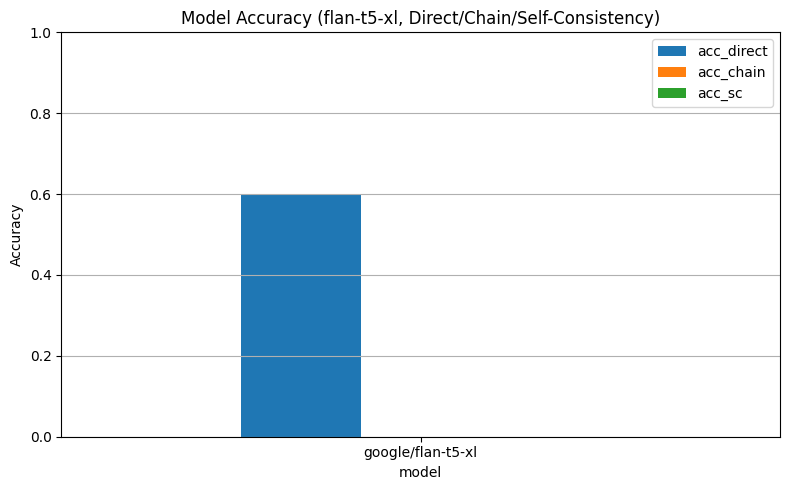

In [ ]:
# === 9-6: 실험 실행 및 결과 시각화 ===
if __name__ == "__main__":
    data = [
        {"question": "What is 7 + 5?",                    "ground_truth": "12"},
        {"question": "If 3 * 4 = 12, what is 12 / 3?",     "ground_truth": "4"},
        {"question": "9 - 2 = ?",                          "ground_truth": "7"},
        {"question": "15 divided by 5 equals ?",           "ground_truth": "3"},
        {"question": "8 times 6 equals ?",                 "ground_truth": "48"},
    ]
    df = pd.DataFrame(data)

    all_results = pd.DataFrame()

    for model_name in MODEL_NAMES:
        result_df = evaluate(df, model_name)
        all_results = pd.concat([all_results, result_df], ignore_index=True)

    # 결과 확인 (정상 컬럼명 사용)
    print(all_results[[
        "question", "prediction_direct", "prediction_chain", "prediction_sc",
        "ground_truth", "acc_direct", "acc_chain", "acc_sc"
    ]])

    # 평균 정확도 출력
    accuracy_df = all_results.groupby('model')[['acc_direct', 'acc_chain', 'acc_sc']].mean()
    print("\nAverage Accuracy:")
    print(accuracy_df)

    # 시각화
    accuracy_df.plot.bar(
        figsize=(8, 5), ylim=(0, 1),
        title="Model Accuracy (flan-t5-xl, Direct/Chain/Self-Consistency)"
    )
    plt.xticks(rotation=0)
    plt.ylabel("Accuracy")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


---
# Q7. : Retrieval-Augmented Generation (RAG) + PEFT (LoRA) Pipeline

In [ ]:
!pip install --upgrade --no-cache-dir datasets bitsandbytes peft transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 313.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 317.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 304.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 334.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 333.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 358.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 284.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 329.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 352.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 253.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 287.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 74.0 MB/s eta 0:00:00


In [ ]:
# 기존의 PyTorch 제거
!pip uninstall torch torchvision torchaudio -y

# 호환 가능한 최신 PyTorch와 torchvision 재설치 (CUDA 12.1 버전으로 설치 권장)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torch 2.7.0
Uninstalling torch-2.7.0:
  Successfully uninstalled torch-2.7.0
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 130.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 110.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 102.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 125.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/

In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())


2.5.1+cu121
0.20.1+cu121
True


In [ ]:
# === 7-1: 환경 설정 & 라이브러리 임포트 ===
import os
import faiss
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForCausalLM,
    BitsAndBytesConfig, GenerationConfig
)
from peft import LoraConfig, TaskType, get_peft_model

# GPU 설정 (PyTorch 및 Transformers는 GPU 사용 가능)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"현재 사용 중인 장치: {device}")

# Faiss를 CPU로 명시적으로 사용 (필수)
faiss_device = 'cpu'
print(f"Faiss는 {faiss_device.upper()} 환경에서 동작 중입니다.")

현재 사용 중인 장치: cuda
Faiss는 CPU 환경에서 동작 중입니다.


In [ ]:
# === 7-2: 문서 코퍼스 로드 및 전처리 ===
# - 'id','text' 컬럼이 있음
from datasets import load_dataset
import pandas as pd

# 캐시 무시하고 항상 새로 다운로드
ds = load_dataset("ag_news", split="train", download_mode="force_redownload")

# DataFrame으로 변환
df_docs = pd.DataFrame({
    "id": list(range(len(ds))),
    "text": ds["text"]
})

# Optional: 상위 10,000개만 사용
df_docs = df_docs.iloc[:10_000].reset_index(drop=True)

print(df_docs.shape)
df_docs.head()



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

(10000, 2)


,id,text
0,0,Wall St. Bears Claw Back Into the Black (Reute...
1,1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...
4,4,"Oil prices soar to all-time record, posing new..."


In [ ]:
# 토크나이저 로드 (retriever용)
tokenizer_retr = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model_retr = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2").to(device)
model_retr.eval()

# --- 문제 시작 ---
def preprocess(text):
    # 간단한 전처리: 소문자화, 특수문자 제거, strip



df_docs["clean"] = df_docs["text"].map(preprocess)

# 문서 임베딩 생성
embeddings = []
with torch.no_grad():
    for txt in tqdm(df_docs["clean"], desc="encode docs"):





# --- 문제 끝 ---

emb_matrix = np.vstack(embeddings).astype("float32")
print("Document embeddings shape:", emb_matrix.shape)

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

encode docs: 100%|██████████| 10000/10000 [00:48<00:00, 206.08it/s]


Document embeddings shape: (10000, 384)


In [ ]:
# === 7-3: FAISS 인덱스 구성 ===
d = emb_matrix.shape[1]
index = faiss.IndexFlatIP(d)   # inner-product (cosine 유사도)
index = faiss.IndexIDMap(index)
# --- 문제 시작 ---

# --- 문제 끝 ---


In [ ]:
# === 7-4: Retriever 함수 ===
def retrieve(query:str, top_k:int=5):
    q_clean = preprocess(query)
    inputs = tokenizer_retr(q_clean, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        q_emb = model_retr(**inputs).last_hidden_state[:,0].cpu().numpy().astype("float32")
    # --- 문제 시작 ---
    # FAISS search
    D, I =




    # --- 문제 끝 ---


In [ ]:
!pip install bitsandbytes

In [ ]:
# === 7-5: RAG 래퍼 정의 ===
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, GenerationConfig
import torch

MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"

# 4-bit quantization 설정 (작은 GPU 메모리에 최적화)
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# 모델 로드
# --- 문제 시작 ---
tokenizer_gen =
model_gen =



# --- 문제 끝 ---

# GenerationConfig 설정
gen_config = GenerationConfig(
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.9,
    do_sample=True,
)

# Retriever 함수와 연동한 최종 RAG 함수
def rag_generate(question:str):
    docs = retrieve(question, top_k=3)
    # --- 문제 시작 ---
    prompt = "### Context:\n"
    for doc_id, _ in docs:
        prompt += df_docs.loc[df_docs.id==doc_id, "clean"].iloc[0] + "\n"
    prompt += f"\n### Question:\n{question}\n### Answer:\n"






    # --- 문제 끝 ---
    return tokenizer_gen.decode(out[0], skip_special_tokens=True)


tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:
for name, module in model_gen.named_modules():
    print(name)



model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.o_proj
model.layers.0.self_attn.qkv_proj
model.layers.0.mlp
model.layers.0.mlp.gate_up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.activation_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.0.resid_attn_dropout
model.layers.0.resid_mlp_dropout
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.o_proj
model.layers.1.self_attn.qkv_proj
model.layers.1.mlp
model.layers.1.mlp.gate_up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.activation_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers.1.resid_attn_dropout
model.layers.1.resid_mlp_dropout
model.layers.2
model.layers.2.self_attn
model.layers.2.self_attn.o_proj
model.layers.2.self_attn.qkv_proj
model.layers.2.mlp
model.layers.2.mlp.gate_up_proj
model.layers.2.mlp.down_proj
model.layers.2.mlp.activation_fn
model.layers.2.input_layerno

In [ ]:
# === 7-6: PEFT (LoRA) 적용 ===
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "self_attn.qkv_proj",
        "self_attn.o_proj",
        "mlp.gate_up_proj",
        "mlp.down_proj"
    ]
)

# --- 문제 시작 ---


# --- 문제 끝 ---


trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543


In [ ]:
# === 7-7: PEFT 미세조정용 데이터셋 준비 ===
# 이미 불러온 df_docs 활용
df_qa = pd.DataFrame({
    "question": df_docs["text"].apply(lambda x: "What is this news about?"),
    "answer": df_docs["text"]
}).iloc[:1000]  # 1,000개만 사용 (조정 가능)

print(df_qa.head())

class QADataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        q = self.df.question.iloc[idx]
        a = self.df.answer.iloc[idx]
        prompt = f"Q: {q}\nA:"
        enc = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt"
        )
        with self.tokenizer.as_target_tokenizer():
            tgt = self.tokenizer(
                a,
                truncation=True,
                max_length=self.max_len,
                padding="max_length",
                return_tensors="pt"
            )
        return {
            "input_ids": enc.input_ids.squeeze(),
            "attention_mask": enc.attention_mask.squeeze(),
            "labels": tgt.input_ids.squeeze()
        }

# 데이터셋 및 DataLoader 준비
# --- 문제 시작 ---
train_ds = QADataset(df_qa, tokenizer_gen)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True)
# --- 문제 끝 ---

print("데이터 로딩 완료. 예시 배치:")
batch = next(iter(train_loader))
print(batch["input_ids"].shape)
print(batch["labels"].shape)


                   question                                             answer
0  What is this news about?  Wall St. Bears Claw Back Into the Black (Reute...
1  What is this news about?  Carlyle Looks Toward Commercial Aerospace (Reu...
2  What is this news about?  Oil and Economy Cloud Stocks' Outlook (Reuters...
3  What is this news about?  Iraq Halts Oil Exports from Main Southern Pipe...
4  What is this news about?  Oil prices soar to all-time record, posing new...
데이터 로딩 완료. 예시 배치:
torch.Size([8, 256])
torch.Size([8, 256])


/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:
# === 7-8: PEFT 학습 루프 ===
optim = torch.optim.AdamW(model_peft.parameters(), lr=2e-4)
model_peft.train()

for epoch in range(3):
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
      # --- 문제 시작 ---








      # --- 문제 끝 ---
    print(f"Epoch {epoch} final loss: {loss.item():.4f}")


Epoch 0: 100%|██████████| 125/125 [00:53<00:00,  2.34it/s]


Epoch 0 final loss: 2.2216


Epoch 1: 100%|██████████| 125/125 [00:53<00:00,  2.35it/s]


Epoch 1 final loss: 2.8561


Epoch 2: 100%|██████████| 125/125 [00:53<00:00,  2.34it/s]

Epoch 2 final loss: 1.4886


In [ ]:
# === 7-9: 평가 및 비교 ===
model_peft.eval()

# df_docs에서 평가 데이터셋 준비 (학습 데이터와 겹치지 않게 설정)
df_test = df_docs.iloc[1000:1200].reset_index(drop=True)  # 200개 샘플 평가

results = []
for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Evaluating"):
    question = "What is this news about?"
    ground_truth = row.text.strip()
    prediction = rag_generate(question).split("### Answer:")[-1].strip()

    results.append({
        "question": question,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "correct": prediction == ground_truth
    })

# 간단한 정확도 측정 (완전 일치 여부)
accuracy = np.mean([r["correct"] for r in results])
print(f"Accuracy (Exact Match): {accuracy:.2%}")

# 결과 예시 확인
for idx in range(3):
    print("\nExample", idx+1)
    print("Q:", results[idx]["question"])
    print("Ground Truth:", results[idx]["ground_truth"])
    print("Prediction:", results[idx]["prediction"])

Evaluating: 100%|██████████| 200/200 [08:37<00:00,  2.59s/it]

Accuracy (Exact Match): 0.00%

Example 1
Q: What is this news about?
Ground Truth: European Union Extends Microsoft-Time Warner Review BRUSSELS, Belgium (AP) -- European antitrust regulators said Monday they have extended their review of a deal between Microsoft Corp. (MSFT) and Time Warner Inc...
Prediction: 

Example 2
Q: What is this news about?
Ground Truth: Patriots Sign Top Pick Watson (Reuters) Reuters - The New England Patriots\Monday announced the signing of first-round draft pick Benjamin\Watson. As per team policy, terms of the tight end's deal were\not released.
Prediction: The news reports on the resignation of John Tate, the former COO of Krispy Kreme Doughnuts, amid a government probe into the company'alled's accounting and earnings forecasts.

Example 3
Q: What is this news about?
Ground Truth: Olympics: Thorpe Beats Phelps as U.S. Fights Gold Gap  ATHENS (Reuters) - Australian swimmer Ian Thorpe beat  arch-rival Michael Phelps in the men's 200-meter freestyle on  Monda

---
# Q8 ~ 9 : Transformer from scratch

8-1 Transformer from scratch
-- Transformer 모델을 직접 python으로 구현해봅니다. Transformer 모델의 핵심 구조인 Encoder 및 decoder를 이루는 multi-head attention layer를 완성하고, dummy data로 이루어진 random 시계열이 에러 없이 학습 loop가 돌아가는지 확인합니다.
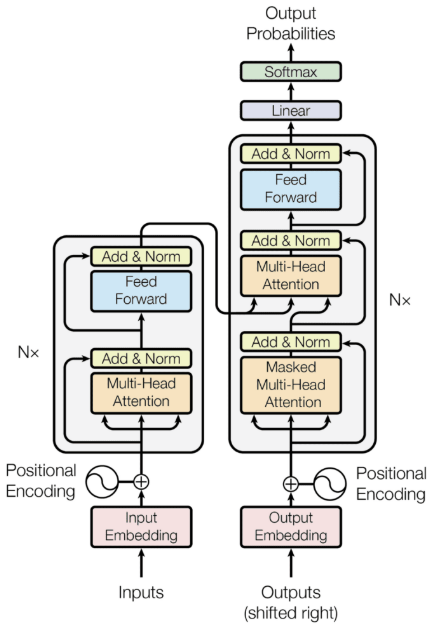

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert #TODO: d_model이 num_heads로 나누어지기 위한 assert 조건

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        TODO: Mask = None일 때와 None이 아닐 때를 구분해야 함
        적절한 attn_probs를 만들어서, 코드의 마지막 두 줄을 변경하지 않아야 함
        """
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        """
        TODO: x가 multi-heads 구조에 compatible하도록 구조 변경
        코드는 return 코드 포함 2줄을 넘기질 말 것.
        """

    def combine_heads(self, x):
        """
        TODO: x를 multi-heads 구조에서 원래 구조로 변경, 아래 return을 얻을 수 있도록 여기에 1줄만 추가해야 함.
        """
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        """
        TODO: 여기에 Q, K, V를 구하는 코드 3줄 작성
        """
        attn_output = #TODO: attn_output을 구하는 1줄 코드 작성
        output = # TODO: output을 구하는 1줄 코드 작성
        return output

In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_hidden):
        super(PositionWiseFeedForward, self).__init__()
        """
        TODO: d_model -> d_hidden -> d_model, activation = relu가 되도록 feedforward neural network의 __init__ 및 forward 함수 작성
        """

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

       """
       TODO: self.posenc 틀 생성
       """

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        """
        TODO: 정의한 self.posenc에 div_term을 apply
        """

    def forward(self, x):
        return x + self.posenc[:, :x.size(1)]

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        """
        TODO:
        - multi-head self-attention module을 d_model 및 num_heads를 고려해 생성
        - Create a position-wise feed-forward network with d_model and hidden layer size d_ff
        - 2개의 layer normalization layers 생성
        - Apply dropout after attention and feed-forward sub-layers
        - Forward 함수를 transformer 모델에 맞추어 residual connection, dropout을 모두 고려해 완성
          - 입력 x에 대해 self-attention 연산을 수행하고 dropout과 residual connection을 적용한 뒤 layer normalization을 수행
          - 이어서 position-wise feed-forward 연산을 수행하고 dropout과 residual connection을 적용한 뒤 두 번째 layer normalization을 수행
        """

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        """
        TODO:
        - multi-head self-attention module을 d_model 및 num_heads를 고려해 생성
        - Create a position-wise feed-forward network with d_model and hidden layer size d_ff
        - 3개의 layer normalization layers 생성
        - Apply dropout after attention and feed-forward sub-layers
        - Forward 함수를 transformer 모델에 맞추어 residual connection, dropout을 모두 고려해 완성
        """

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):

        """
        TODO: source 및 target에 알맞는 mask matrix 생성
        """

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

아래 주어진 src_data 및 tgt_data는 random dummy data입니다. 이 data로 학습을 진행할 경우 train loss는 줄어들지 않을 것입니다. 하지만 error 없이 이 코드까지 돌아갈 수 있도록 윗 부분의 TODO를 완성해야 합니다.

In [ ]:
src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 100
dropout = 0.1

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

# Generate random sample data
src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()

for epoch in range(10):
    optimizer.zero_grad()
    output = transformer(src_data, tgt_data[:, :-1])
    loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 7.395689487457275
Epoch: 2, Loss: 7.75587272644043
Epoch: 3, Loss: 7.378458023071289
Epoch: 4, Loss: 7.2648234367370605
Epoch: 5, Loss: 7.210461139678955
Epoch: 6, Loss: 7.150683403015137
Epoch: 7, Loss: 7.076231002807617
Epoch: 8, Loss: 7.000368595123291
Epoch: 9, Loss: 6.923316955566406
Epoch: 10, Loss: 6.864278793334961


8-2 다음 pkl 데이터를 적절한 Tokenization 및 전처리 알고리즘을 통해 위 dummy data의 형태와 같이 만들어야 합니다:

english-german-both.pkl


아래 주어진 PrepareDataset class를 이용하세요.

In [ ]:
from pickle import load

class PrepareDataset:
    def __init__(self, **kwargs):
        super(PrepareDataset, self).__init__(**kwargs)
        self.n_sentences = 10000
        self.train_split = 0.9

    def create_tokenizer(self, dataset):
        """
        TODO: 적절한 tokenizer를 정의하세요
        """
        return tokenizer

    def find_seq_length(self, dataset):
        return max(len(seq.split()) for seq in dataset)

    def find_vocab_size(self, tokenizer, dataset):
        """
        TODO: vocab_size를 리턴해야 합니다. return 쪽의 줄을 바꾸어도 좋습니다.
        """

        return len(tokenizer.word_index) + 1

    def __call__(self, filename, **kwargs):
        clean_dataset = load(open(filename, 'rb'))

        dataset = clean_dataset[:self.n_sentences, :]

        for i in range(dataset[:, 0].size):
            dataset[i, 0] = "<START> " + dataset[i, 0] + " <EOS>"
            dataset[i, 1] = "<START> " + dataset[i, 1] + " <EOS>"

        # Split the dataset
        train = dataset[:int(self.n_sentences * self.train_split)]

        # Prepare tokenizer for the encoder input
        enc_tokenizer = self.create_tokenizer(train[:, 0])
        enc_seq_length = self.find_seq_length(train[:, 0])
        enc_vocab_size = self.find_vocab_size(enc_tokenizer, train[:, 0])

        # Encode and pad the input sequences
        trainX = enc_tokenizer.texts_to_sequences(train[:, 0])

        # Prepare tokenizer for the decoder input
        dec_tokenizer = self.create_tokenizer(train[:, 1])
        dec_seq_length = self.find_seq_length(train[:, 1])
        dec_vocab_size = self.find_vocab_size(dec_tokenizer, train[:, 1])

        # Encode and pad the input sequences
        trainY = dec_tokenizer.texts_to_sequences(train[:, 1])

        return trainX, trainY, train, enc_seq_length, dec_seq_length, enc_vocab_size, dec_vocab_size

9-1 위 8-2의 데이터셋을 활용하여 8-1에서 만든 Transformer 모델을 이용해 machine translator가 학습이 이루어지는지 검증하세요.
epoch별 train loss를 plot하여, 실제로 train loss가 떨어지고 있다는 것을 검증하면 됩니다.

Epoch 1/10 - Train Loss: 5.5293
Epoch 2/10 - Train Loss: 5.2945
Epoch 3/10 - Train Loss: 5.2635
Epoch 4/10 - Train Loss: 5.2510
Epoch 5/10 - Train Loss: 5.2449
Epoch 6/10 - Train Loss: 5.2386
Epoch 7/10 - Train Loss: 5.2359
Epoch 8/10 - Train Loss: 5.2337
Epoch 9/10 - Train Loss: 5.2308
Epoch 10/10 - Train Loss: 5.2291


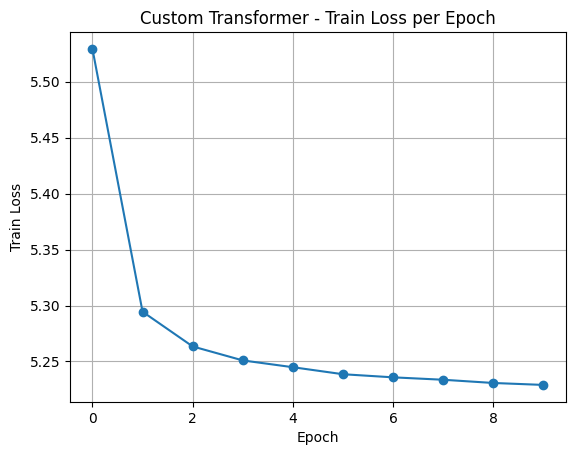

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
# 학습 파라미터
epochs = 10
batch_size = 64
learning_rate = 0.001

prepare = PrepareDataset()

trainX, trainY, train_raw, enc_seq_length, dec_seq_length, enc_vocab_size, dec_vocab_size = prepare("/english-german-both.pkl")

# 텐서로 변환
import torch
from torch.utils.data import TensorDataset, DataLoader

trainX = torch.tensor(trainX, dtype=torch.long)
trainY = torch.tensor(trainY, dtype=torch.long)

dataset = TensorDataset(trainX, trainY)
loader = DataLoader(dataset, batch_size=64, shuffle=True)




# 모델 초기화
model = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []

# 학습 루프
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for src_batch, tgt_batch in loader:
        optimizer.zero_grad()

        # Shift target for teacher forcing
        output = model(src_batch, tgt_batch[:, :-1])
        output = output.reshape(-1, tgt_vocab_size)
        target = tgt_batch[:, 1:].reshape(-1)

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}")

# Loss 시각화
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Custom Transformer - Train Loss per Epoch")
plt.grid()
plt.show()

9-2 위 8-2의 데이터셋을 활용하여 pytorch의 transformer 모델을 import하여, machine translator가 학습이 이루어지는지 검증하세요.

Epoch 1/10 - Train Loss: 5.5299
Epoch 2/10 - Train Loss: 5.2911
Epoch 3/10 - Train Loss: 5.2607
Epoch 4/10 - Train Loss: 5.2511
Epoch 5/10 - Train Loss: 5.2443
Epoch 6/10 - Train Loss: 5.2405
Epoch 7/10 - Train Loss: 5.2370
Epoch 8/10 - Train Loss: 5.2333
Epoch 9/10 - Train Loss: 5.2298
Epoch 10/10 - Train Loss: 5.2274


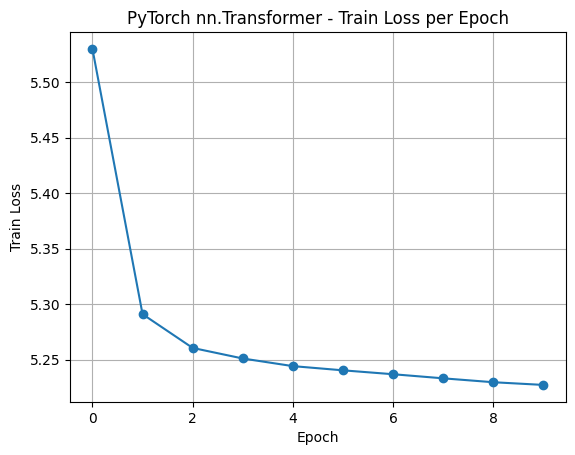

In [ ]:
from torch.nn import Transformer

class SimpleTransformerModel(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, nhead=8, num_layers=6):
        super().__init__()

        '''
        TODO 입력 문장을 임베딩하는 층 (단어 인덱스를 고정 차원 벡터로 변환)

        TODO Transformer 모델 구성
        - d_model: 임베딩 차원
        - nhead: 멀티 헤드 어텐션의 헤드 수
        - num_encoder_layers: 인코더 층 개수
        - num_decoder_layers: 디코더 층 개수


        TODO Transformer 출력 → tgt_vocab 크기로 projection 하는 FC layer
        '''


    def forward(self, src, tgt):
        '''
        TODO 임베딩 후 차원 순서 변경 (batch first → sequence first)
        Transformer는 (S, N, E) 형식을 요구함


        TODO Transformer 인코더-디코더 구조 실행


        TODO 출력 결과를 다시 (batch first)로 변경하고 vocab 차원으로 변환
        '''
        return self.fc_out(output).permute(1, 0, 2)


# 모델 학습
model = SimpleTransformerModel(src_vocab_size, tgt_vocab_size)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for src_batch, tgt_batch in loader:
        optimizer.zero_grad()
        output = model(src_batch, tgt_batch[:, :-1])
        output = output.reshape(-1, tgt_vocab_size)
        target = tgt_batch[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}")

# 시각화
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("PyTorch nn.Transformer - Train Loss per Epoch")
plt.grid()
plt.show()

Q10. 기계 구조물의 이상 가동을 탐지하기 위해, 설비 별로 온도 센서를 부착하여 일정 시간마다 센서 값을 받아서 분석하고자 합니다. 각 엑셀 파일은 설비의 이름을 나타냅니다. 엑셀 파일을 열어 보면, 다음과 같은 데이터의 특징을 발견할 수 있습니다:
===
- 설비의 전원 ON/OFF 상태에 따라 센서 값이 다릅니다 (전원이 OFF 상태인 경우는 ON인 경우보다 주로 낮은 센서 값을 보여줍니다)
- 센서 값이 간혹 1~2개씩 튀는 경우가 있습니다.
- 센서 값을 읽는 데 실패하여 NaN이 저장되는 경우가 있습니다.
- 설비를 점검하는 기간이 존재합니다. 이 기간 동안에는 위의 경우보다 긴 시간동안 센서 값이 위아래로 요동치는 경향이 있습니다.

설비의 온도 변화 패턴 학습을 위한 데이터 수집에 앞서, 위 상황들에 대한 이상치 처리 (outlier rejection)를 하고자 합니다. 아래와 같이 outlier를 정의합니다:
- 설비의 전원이 OFF인 경우는 outlier data로 처리함
- 센서 값이 비이상적으로 튀는 경우 outlier data로 처리함
- 설비 점검 기간 중 튀는 모든 구간의 데이터를 outlier로 처리함
- 센서 값이 NaN으로 저장되는 경우는 센서 값이 999로 표기되어 있고, 이는 outlier로 처리됩니다.
다만, 전체 데이터를 모두 보고 outlier detection을 하지는 않습니다. 데이터가 실시간으로 12개씩 새로 들어온다고 가정하고, 기존 데이터를 바탕으로 새로 들어오는 데이터의 outlier 여부를 판단하는 모델이 필요합니다.

각 설비별 로그 파일에서는 outlier로 분류된 데이터를 확인할 수 있습니다.
지금까지 배운 시계열 분석 model 중 자신 있는 model을 활용하여, 실시간 outlier detection 알고리즘을 완성해 보세요.

- outlier_initialization 함수에서는 설비별 첫 5000개 데이터 (1~5000행)에 대한 초기 outlier 분류 작업을 수행하는 알고리즘을 만들어 주세요

- outlier_classification 함수에서는 초기 분류 작업 이후, 실시간으로 데이터가 12개씩 들어오게 되는데, 이 때, 가장 최근 8064개 데이터를 바탕으로 outlier 여부를 결정해 주세요.

- 실시간 데이터가 8064개 이하로 쌓인 경우에는, 모아진 데이터를 바탕으로 outlier 여부를 결정해 주세요. 즉, fixed-window를 사용하지 않아야 합니다.

In [ ]:
import random
import numpy as np
import pandas as pd
def load_and_preprocess_data(file_path):

    try:
      df = pd.read_csv(file_path,  parse_dates=['TIMESTAMP_DT'])
    except:
      df = pd.read_csv(file_path, encoding='cp949', parse_dates=['TIMESTAMP_DT'])
    df.set_index('TIMESTAMP_DT', inplace=True)

    df.index = df.index.round('5min')
    df = df[~df.index.duplicated(keep='first')]

    df = df.asfreq('5min')

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_resampled = df.resample('5min').mean(numeric_only=True)

    df_resampled['CH_VALUE'] = df_resampled['CH_VALUE'].fillna(999)

    other_cols = df_resampled.columns.difference(['CH_VALUE'])
    df_resampled[other_cols] = df_resampled[other_cols].interpolate(method='linear')

    t0 = df_resampled.index[0]
    df_resampled['time_days'] = (df_resampled.index - t0).total_seconds() / 86400

    df_resampled = df_resampled.reset_index()

    return df_resampled

In [ ]:
import os, math, pandas as pd, numpy as np
import matplotlib.pyplot as plt

def outlier_initialization(df_train, TRAIN_WINDOW):
    """
    TODO: 초기 outlier 분류 알고리즘
    """
    return df_train_final, detector


def outlier_classification(detector, df_all, TRAIN_WINDOW, batch_size):
    """
    TODO: 실시간 outlier 분류 알고리즘
    """
    return df_batch

[0.08560801 0.18520622 0.30079296 ... 0.02102163 0.11681976 0.0592379 ]
8064
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

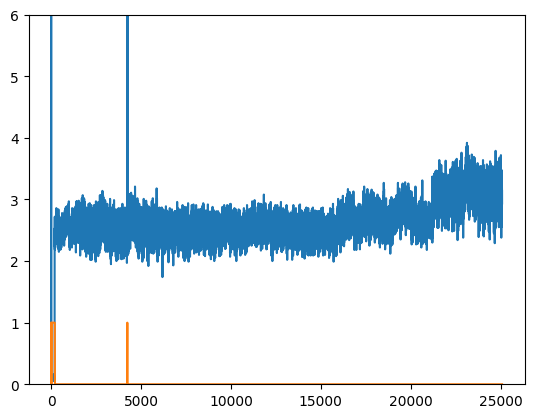

In [ ]:
batch_size = 288
TRAIN_TERM = 28


w_size = 288
FUTURE_IDX = 56 * w_size
STAT_IDX = 7 * w_size
TRAIN_WINDOW = TRAIN_TERM * w_size

FILE_PATH = 'device1.csv'
"""
해당 파일명을 바꾸어도, 동일한 알고리즘, 동일한 hyperparameter 세팅으로 outlier detection이 이루어져야 함.
파일은 3개 존재함
"""
# data preprocessing
df = load_and_preprocess_data(FILE_PATH)

# Train data
IDX_START = 5000
df_train = df.loc[:IDX_START-1].copy()
df_test = df.loc[IDX_START:].copy()

# Outlier Detection
df_train_, detector_ = outlier_initialization(df_train.iloc[::-1].reset_index(drop=True), TRAIN_WINDOW)
df_train, detector = outlier_initialization(df_train.copy(), TRAIN_WINDOW)
df_train_ = df_train_.iloc[::-1].reset_index(drop = True)
df_train_forgmm = df_train.copy()
df_train_forgmm["OUTLIER"] = df_train["OUTLIER"] * df_train_["OUTLIER"]


# 결과 저장 dataframe
results = list()
df_all = df_train_forgmm.copy()


for start in range(IDX_START, len(df) - 56 * 288, batch_size):
    # 매 스텝당 좌표 정의
    p0 = start + batch_size - 1
    pt, ps, pe = p0 - TRAIN_WINDOW + 1, p0 - STAT_IDX + 1, p0 + FUTURE_IDX
    # start    : 배치 처음 인덱스
    # p0       : 배치 마지막 인덱스
    # pt Train : 시작점
    # ps       : 통계 산출 시작점
    # pe       : 예측 종료점

    # ---------------- #
    #     배치 데이터     #
    # ---------------- #
    # 1. 배치 데이터 업데이트
    df_batch = df.loc[start:p0]

    # 2. 총 관측 데이터
    df_all = pd.concat([df_all, df_batch])

    # 3. 배치 단위 이상치 분류
    df_batch = outlier_classification(detector, df_all, TRAIN_WINDOW, batch_size)


    df_all.loc[df_batch.index, "OUTLIER"] = df_batch["OUTLIER"]

# Save result
df_all.to_csv(f"df_all.csv", index=True)

plt.plot(df_all["CH_VALUE"])
plt.plot(df_all["OUTLIER"])
plt.ylim(0, 6)
plt.show()

df_all.csv에 저장된 분류 알고리즘 결과가, 실제 결과인 device_n_answer에 저장된 outlier 결과와 95% 이상 일치해야 합니다.

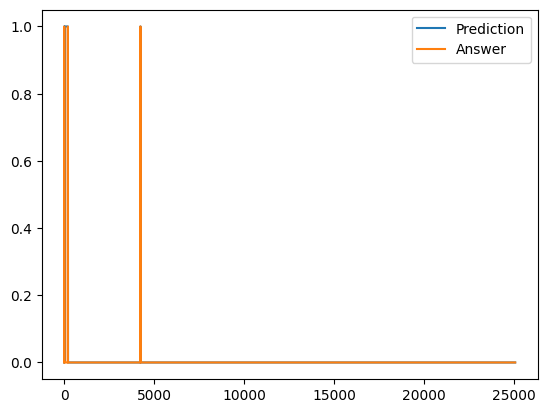

Accuracy: 99.20% (24879 / 25080)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = 'device1_answer.csv'
# 정답 파일 (device1)
answer_df = pd.read_csv(FILE_PATH, parse_dates=['TIMESTAMP_DT'])


# 병합: 공통 TIMESTAMP_DT 기준
merged = pd.merge(
    df_all[['TIMESTAMP_DT', 'OUTLIER']],
    answer_df[['TIMESTAMP_DT', 'OUTLIER']],
    on='TIMESTAMP_DT',
    how='inner',
    suffixes=('_pred', '_true')
)

# 비교: 인덱스 무시
count_same = np.sum(merged['OUTLIER_pred'].values == merged['OUTLIER_true'].values)
count_total = len(merged)
accuracy = count_same / count_total * 100

# 시각화
plt.plot(merged['OUTLIER_pred'].values, label='Prediction')
plt.plot(merged['OUTLIER_true'].values, label='Answer')
plt.legend()
plt.show()

print(f"Accuracy: {accuracy:.2f}% ({count_same} / {count_total})")


[주관식 과제 수행 시 유의사항]

※ 주관식 과제의 채점 기준은 다음과 같습니다

결과 출력값이 주어진 것과 동일하게 표기되어 있는가 (일부 변동성을 띠는 숫자는 제외)
문제 내에서 요구하는 요구사항들을 모두 이행하였는가
따라서 문제 내에서 요구하는 작은 요소라도 반드시 놓치지 마시고, 모두 고려하여 코드를 작성해주시기 바랍니다.

실제 현업에서의 데이터 분석가는 세심함과 정확성이 요구되는 작업입니다.

특히, 조건과 컬럼 하나하나를 명확하게 설정하고 관리하는 것이 중요합니다.

이러한 부분을 주관식 문제를 통해 반영하고자 하였습니다.

과제 평가 시 해당 내용들을 기준으로 평가하므로, 이 점을 유념하여 과제를 수행해주시기 바랍니다.

만약 위 기준에 부합하지 않는 항목이 있을 경우, 해당 문제는 오답으로 0점 처리되오니 참고하시기 바랍니다.